# Chargement des bibliothèques

In [461]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

# 1. Collecte et préparation des données

In [462]:
tickers = ('AAPL', 'JPM','JNJ', 'XOM','AMZN','PG','NEE','CAT','AMT','GLD')
data = yf.download (tickers, start='2017-01-01', end='2022-12-31')['Close']
#data = pd.DataFrame (data)

[*********************100%***********************]  10 of 10 completed


In [463]:
train_data = data [:'2021']
test_data = data ['2022':]

# 2. Estimation des paramètres

In [464]:
returns = np.log (train_data/train_data.shift()).dropna()
y_returns = np.mean (returns, axis=0) * 252  #rendements annuels

#Construction de la matrice de covariane de Ledoit-Wolf
lw = LedoitWolf().fit (returns)
y_cov = pd.DataFrame (lw.covariance_ * 252, index = returns.columns, columns = returns.columns)

print (f'Vecteur de rendements annuels : \n{y_returns}\n'
       f'Matrice de covariances annuelles : \n{y_cov}\n'
       f'Coefficient de shrinkage = {lw.shrinkage_}')

Vecteur de rendements annuels : 
Ticker
AAPL    0.374853
AMT     0.222609
AMZN    0.297888
CAT     0.183966
GLD     0.087476
JNJ     0.104523
JPM     0.146771
NEE     0.253214
PG      0.161561
XOM    -0.026924
dtype: float64
Matrice de covariances annuelles : 
Ticker      AAPL       AMT      AMZN       CAT       GLD       JNJ       JPM  \
Ticker                                                                         
AAPL    0.092031  0.031680  0.055093  0.039172  0.002229  0.024069  0.039337   
AMT     0.031680  0.066711  0.021861  0.021575  0.004726  0.024371  0.026883   
AMZN    0.055093  0.021861  0.085569  0.029572  0.002456  0.016181  0.022458   
CAT     0.039172  0.021575  0.029572  0.097267 -0.001764  0.025089  0.060442   
GLD     0.002229  0.004726  0.002456 -0.001764  0.019548  0.001437 -0.004295   
JNJ     0.024069  0.024371  0.016181  0.025089  0.001437  0.041246  0.024966   
JPM     0.039337  0.026883  0.022458  0.060442 -0.004295  0.024966  0.089335   
NEE     0.026825  0

# 3. Construction du portefeuille de Markowitz

## 3.1. Définition des fonctions utiles

In [465]:
def portfolio_returns (weights, returns) : 
    return weights @ returns

def portfolio_std (weights, mat_cov) : 
    return np.sqrt (weights.T @ mat_cov @ weights)

def portfolio_sharpe_ratio (weights, returns, mat_cov, rf) :
    return (portfolio_returns (weights, returns) - rf ) / portfolio_std (weights, mat_cov)


## 3.2. Optimisation du ratio de Sharpe

In [466]:
risk_free_rate  = 0.042

# Définition des bornes et contraintes
bornes = [(0,1)] * len(tickers)
contraintes = {'type' : 'eq', 'fun' : lambda w : np.sum (w) -1}

# Maximisation du ratio de sharpe
res_max_sharpe = minimize (fun = lambda w : -portfolio_sharpe_ratio(w, y_returns, y_cov, risk_free_rate),
                           x0 = np.repeat (1/len(tickers),len(tickers)),
                           method = 'SLSQP',
                           bounds=bornes,
                           constraints = contraintes) 

sharpe_weights = res_max_sharpe.x
ret_sharpe = portfolio_returns (sharpe_weights, y_returns)

In [467]:
print (f'rendement sharpe : {portfolio_returns (sharpe_weights, y_returns)}\n'
       f'Variance sharpe : {portfolio_std (sharpe_weights, y_cov)}')

rendement sharpe : 0.2687582864880301
Variance sharpe : 0.181524495106807


## 3.3. Calcul de la frontière efficiente

In [468]:
#Calcul du portefeuille de variance minimale
res_var_min = minimize (fun = lambda w : portfolio_std (w,y_cov),
                        x0=np.repeat (1/len(tickers), len(tickers)),
                        method ='SLSQP',
                        bounds= bornes,
                        constraints=contraintes)


var_min_ret = portfolio_returns (res_var_min.x, y_returns)

#Calcul de la frontière efficiente
target_ret = np.linspace (var_min_ret, np.max (y_returns), 100) #différents rendements à égaler pour calculer le portefeuille efficient
eff_weights = []
eff_returns = []
eff_std = []
sharpe_r = []

for ret in target_ret : 
    ret_constraint = {'type':'eq', 'fun' : lambda w, r = ret : portfolio_returns (w,y_returns) - r } #Contrainte pour égaler le rendement fixé à chaque itération

    ret_min = minimize (fun = lambda w :portfolio_std (w, y_cov),
                        x0=np.repeat (1/len(tickers),len (tickers)),
                        method = 'SLSQP',
                        bounds = bornes,
                        constraints= (contraintes,ret_constraint))

    if ret_min.success : 
        w = ret_min.x
        eff_weights.append (w)
        eff_returns.append (portfolio_returns(w, y_returns))
        eff_std.append (portfolio_std (w,y_cov))
        sharpe_r.append (portfolio_sharpe_ratio (w,y_returns, y_cov, risk_free_rate))

eff_front = pd.DataFrame (eff_weights, columns= y_returns.index)
eff_front ['Port_Return'] = eff_returns
eff_front ['Port_std'] = eff_std
eff_front ['Sharpe_R'] = sharpe_r

In [469]:
eff_front

Ticker,AAPL,AMT,AMZN,CAT,GLD,JNJ,JPM,NEE,PG,XOM,Port_Return,Port_std,Sharpe_R
0,0.000000e+00,0.000000e+00,5.310077e-02,3.558041e-03,6.032092e-01,1.267389e-01,6.724474e-02,1.761829e-18,1.231251e-01,2.302327e-02,0.111628,0.109681,0.634821
1,3.794708e-19,5.421011e-19,5.817223e-02,6.088583e-03,5.993980e-01,1.234508e-01,7.037360e-02,2.168404e-19,1.273835e-01,1.513331e-02,0.114287,0.109706,0.658917
2,0.000000e+00,9.757820e-19,6.222543e-02,9.062097e-03,5.959098e-01,1.197989e-01,7.205897e-02,3.637051e-03,1.288833e-01,8.424461e-03,0.116946,0.109782,0.682675
3,0.000000e+00,0.000000e+00,6.479685e-02,1.264616e-02,5.930236e-01,1.169949e-01,7.348662e-02,9.728453e-03,1.278865e-01,1.436946e-03,0.119605,0.109902,0.706127
4,0.000000e+00,5.090937e-19,7.033114e-02,1.474015e-02,5.873543e-01,1.105874e-01,7.208243e-02,1.824280e-02,1.266617e-01,0.000000e+00,0.122263,0.110067,0.729221
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9.125666e-01,4.186692e-17,0.000000e+00,6.486782e-17,2.814470e-17,0.000000e+00,0.000000e+00,8.743342e-02,0.000000e+00,0.000000e+00,0.364218,0.285234,1.129660
96,9.344249e-01,0.000000e+00,1.804112e-16,1.367994e-18,0.000000e+00,2.284208e-17,3.985299e-17,6.557506e-02,1.147587e-17,0.000000e+00,0.366876,0.289638,1.121665
97,9.562833e-01,5.791071e-19,0.000000e+00,1.464438e-17,0.000000e+00,3.870404e-17,0.000000e+00,4.371671e-02,2.000656e-17,0.000000e+00,0.369535,0.294130,1.113573
98,9.781416e-01,1.186688e-17,0.000000e+00,0.000000e+00,1.008888e-17,4.826866e-17,0.000000e+00,2.185835e-02,0.000000e+00,0.000000e+00,0.372194,0.298708,1.105408


## 3.4. Représentation graphique

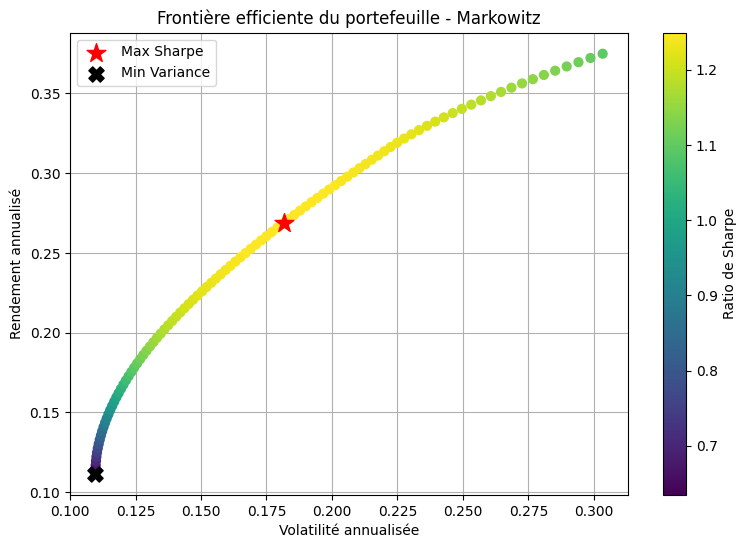

In [470]:
#Représentation graphique
fig, ax = plt.subplots (figsize =(9,6))

sc = ax.scatter (eff_front ['Port_std'], eff_front ['Port_Return'], c = eff_front ['Sharpe_R'], cmap='viridis', s=40, zorder = 2)
plt.colorbar(sc, ax = ax, label='Ratio de Sharpe')


ax.scatter (portfolio_std (sharpe_weights,y_cov), portfolio_returns (sharpe_weights, y_returns), c='red', marker = '*', s = 200, zorder = 3, label = 'Max Sharpe') #Portefeuille max Sharpe

ax.scatter (portfolio_std (res_var_min.x, y_cov), var_min_ret, c = 'black', marker = 'X', s = 120, zorder = 3, label = 'Min Variance') #portefeuille variance minimale


plt.xlabel ('Volatilité annualisée')
plt.ylabel ('Rendement annualisé')
plt.title ('Frontière efficiente du portefeuille - Markowitz')

plt.grid()
plt.legend ()


# 4. Construction du portefeuille de Black-Litterman

## 4.1. Calcul des rendements d'équilibre (portefeuille de référence)

In [471]:
# Récupération des capitalisation boursières
market_caps = {}
for ticker in list (y_returns.index) : 
    info = yf.Ticker (ticker).info
    market_caps [ticker] = info.get ('marketCap') #Attention ! Les capitatlisations sont celles actuelles, pas celles de 2021
    
market_caps = pd.DataFrame.from_dict (market_caps, orient='index', columns=['Market_Cap']).rename(columns= {'index':'Ticker'})

# Calcul du poids de chaque actif
market_caps.loc [market_caps['Market_Cap'].isna(), 'Market_Cap'] = 0
market_caps ['Wi_eq'] = market_caps ['Market_Cap'] / market_caps ['Market_Cap'].sum()
print (f'Capitalisation boursières et poids du portefeuille de référence :\n  {market_caps}')

# Calcul du coefficient d'aversion au risque
market_var = market_caps['Wi_eq'].values @ y_cov.values @ market_caps['Wi_eq'].values
risk_avers = (portfolio_returns(market_caps['Wi_eq'], y_returns) - risk_free_rate) / market_var

print()
print (f'Coefficient d\'aversion au risque : {risk_avers}')
print()
# Calcul du vecteur de rendements d'équilibre implicites (portefeuille de référence)
ref_ret = risk_avers * (y_cov @ market_caps ['Wi_eq'])

print (f'Rendements du portefeuille de référence :\n {ref_ret}')

Capitalisation boursières et poids du portefeuille de référence :
          Market_Cap     Wi_eq
AAPL  4.275930e+12  0.430828
AMT   8.720586e+10  0.008787
AMZN  2.566108e+12  0.258552
CAT   4.194012e+11  0.042257
GLD   0.000000e+00  0.000000
JNJ   5.798264e+11  0.058421
JPM   8.593728e+11  0.086587
NEE   1.793412e+11  0.018070
PG    3.483817e+11  0.035102
XOM   6.093487e+11  0.061396

Coefficient d'aversion au risque : 4.575177439173877

Rendements du portefeuille de référence :
 Ticker
AAPL    0.292601
AMT     0.125585
AMZN    0.238794
CAT     0.183522
GLD     0.006366
JNJ     0.105139
JPM     0.181198
NEE     0.108833
PG      0.098647
XOM     0.158544
dtype: float64


## 4.2. Définition des views de l'investisseur (portefeuille tactique)

Toutes les views sont exprimés par rapport aux dynamiques de l'époque

View 1 : L'action Apple génère un rendement annuel de 20% du fait de la hype de la marque et de ses nouvelles sorties annuelles (Macbook, Airpods) et de ses services (cloud, apple music) qui se développent

View 2 : L'action Amazon (AMZN) superforme l'action (XOM) de 10% par an du fait de la montée en puissance du e-commerce après la crise de la covid en 2020

View 3 : L'action (NEE) superforme l'action l'action Caterpillar (CAT) de 5% par an du fait de la transition énergétique qui favorisait les materiaux renouvelables au détriment de l'industrie traditionnelle

View 4 : GLD génère un rendement annuel de 4%, l'or constitue une valeur refuge

In [472]:
#Paramètre arbitraire (mesure l'importance relative des rendements du marché et des prévisions tactiques)
teta = 1/len (train_data)  
print (teta)

0.0007942811755361397


In [473]:
#Matrice Q des excédents de rendements estimé par l'investisseur

Q = np.array ([0.20, 0.10, 0.05, 0.04])

#Matrice P spécifiant les vues de l'investisseurs

tickers_sorted = list(y_returns.index)  

def make_view(long=None, short=None):
    row = np.zeros(len(tickers_sorted))
    if long:  row[tickers_sorted.index(long)]  =  1
    if short: row[tickers_sorted.index(short)] = -1
    return row

P = np.array([
    make_view(long='AAPL'),
    make_view(long='AMZN', short='XOM'),
    make_view(long='NEE',  short='CAT'),
    make_view(long='GLD'),
])

In [474]:
#Calcul de la matrice omega, matrice de covariance des erreurs sur les opinions

omega = teta * (P @ y_cov @ P.T)
print (omega)

          0         1         2         3
0  0.000073  0.000018 -0.000010  0.000002
1  0.000018  0.000111  0.000018  0.000003
2 -0.000010  0.000018  0.000092  0.000006
3  0.000002  0.000003  0.000006  0.000016


## 4.3. Portefeuille mixte

In [475]:
#Termes intermédiaires 

tau_cov = teta * y_cov
tau_cov_inv = np.linalg.inv (tau_cov)
omega_inv = np.linalg.inv (omega)

#Mise à jour bayésienne
M = np.linalg.inv (tau_cov_inv + P.T @ omega_inv @ P)
mu_bl = M @ (tau_cov_inv @ ref_ret + P.T @ omega_inv @ Q)

mu_bl = pd.Series (mu_bl, index = y_returns.index)
print (f"Rendements Black-Litterman : \n : {mu_bl.round (4)}")



Rendements Black-Litterman : 
 : Ticker
AAPL    0.2463
AMT     0.1207
AMZN    0.2128
CAT     0.1282
GLD     0.0232
JNJ     0.0931
JPM     0.1416
NEE     0.1159
PG      0.0910
XOM     0.1227
dtype: float64


In [476]:
rendements = pd.DataFrame (columns= ('mu_bl', 'ref_ret', 'y_returns'), index = y_returns.index)
rendements ['mu_bl'] = mu_bl
rendements ['ref_ret'] = ref_ret
rendements ['y_returns'] = y_returns
print (rendements)

           mu_bl   ref_ret  y_returns
Ticker                               
AAPL    0.246301  0.292601   0.374853
AMT     0.120652  0.125585   0.222609
AMZN    0.212816  0.238794   0.297888
CAT     0.128235  0.183522   0.183966
GLD     0.023183  0.006366   0.087476
JNJ     0.093061  0.105139   0.104523
JPM     0.141562  0.181198   0.146771
NEE     0.115890  0.108833   0.253214
PG      0.091049  0.098647   0.161561
XOM     0.122691  0.158544  -0.026924


On observe un écart modéré sur les actions pour lesquels nous avons émis des pronostiques

AAPL : mu_bl = 0.247 vs prior 0.293 → la view à 20% tire le rendement vers le bas par rapport au prior, ce qui est logique (prior AAPL était déjà très élevé à 29%)
AMZN : mu_bl = 0.213 vs prior 0.239 → même effet, la view relative AMZN/XOM modère le prior
GLD : mu_bl = 0.023 vs prior 0.007 → la view à 4% tire GLD vers le haut depuis un prior quasi nul, c'est exactement le comportement attendu
XOM : mu_bl = 0.122 vs prior 0.158 → pénalisé par la view relative AMZN surperforme XOM

Les actions sans pronostic restent proches du prior :
JNJ, JPM, PG, AMT, CAT, NEE bougent très peu entre mu_bl et ref_ret, ce qui est exactement le comportement attendu.

## 4.4. Optimisation des rendements mixtes (portefeuille de Black-Litterman)

In [477]:
#Calcul de la nouvelle matrice de covariance

cov_bl = y_cov + M

In [478]:
#Calcul du vecteur poids pour le portefeuille de Black - Litterman

res_bl = minimize (fun = lambda w : -portfolio_sharpe_ratio (w, mu_bl, cov_bl, risk_free_rate),
                   x0= np.repeat (1/len(mu_bl.index), len (mu_bl.index)),
                   method= 'SLSQP',
                   constraints= contraintes,
                   bounds=bornes)

wi_bl = pd.DataFrame (np.round (res_bl.x,4), columns= ['wi_bl'], index= mu_bl.index)
print (f' Vecteur poids portefeuille Black - Litterman :\n {wi_bl}')

 Vecteur poids portefeuille Black - Litterman :
          wi_bl
Ticker        
AAPL    0.5433
AMT     0.0000
AMZN    0.3242
CAT     0.0000
GLD     0.0000
JNJ     0.0000
JPM     0.0485
NEE     0.0840
PG      0.0000
XOM     0.0000


## 4.5. Comparaison des portefeuilles

In [479]:
comparison = pd.DataFrame({
    'Markowitz': sharpe_weights,
    'Black-Litterman': res_bl.x
}, index=mu_bl.index)

print(comparison.round(4))

# Métriques résumées
print(f'\nMarkowitz   — Rendement: {portfolio_returns(sharpe_weights, y_returns):.4f}, '
      f'Vol: {portfolio_std(sharpe_weights, y_cov):.4f}, '
      f'Sharpe: {portfolio_sharpe_ratio(sharpe_weights, y_returns, y_cov, risk_free_rate):.4f}')

print(f'Black-Litterman — Rendement: {portfolio_returns(res_bl.x, mu_bl):.4f}, '
      f'Vol: {portfolio_std(res_bl.x, cov_bl):.4f}, '
      f'Sharpe: {portfolio_sharpe_ratio(res_bl.x, mu_bl, cov_bl, risk_free_rate):.4f}')

        Markowitz  Black-Litterman
Ticker                            
AAPL       0.3401           0.5433
AMT        0.0000           0.0000
AMZN       0.1477           0.3242
CAT        0.0000           0.0000
GLD        0.1956           0.0000
JNJ        0.0000           0.0000
JPM        0.0000           0.0485
NEE        0.3166           0.0840
PG         0.0000           0.0000
XOM        0.0000           0.0000

Markowitz   — Rendement: 0.2688, Vol: 0.1815, Sharpe: 1.2492
Black-Litterman — Rendement: 0.2194, Vol: 0.2501, Sharpe: 0.7093


Nous nous attendions à un portefeuille BL plus diversifié mais il est plus concentré sur AAPL (54% vs 34%) et avec un Sharpe nettement plus faible (0.71 vs 1.25).

La diversification de BL ne vient pas du fait que les rendements sont "moins extrêmes" en absolu — elle vient de l'ordre relatif des actifs. Avec ton τ très petit (≈0.0008), μ_BL reste très proche du prior CAPM. En observant les rentabilités, on remarque de markowitz et de BL, on voit par exemple que l'action NEE perd énormément d'attractivité et l'action APPLE a toujours la plus grosse rentabilité (peut-être la raison de sa surpondération)

En faisant varier teta nous remarquons qu'il n'a presqu'aucun effet, pour avoir une réelle différence il faudrait faire varier indépendamment la matrice omega de covariance des erreurs sur les opinions

# 5. Simulations de Monte Carlo

## 5.1. Projection de la valeur du portefeuille

Nous utiliserons la technique de Geometric Brownian Motion multivarie, elle consiste à simuler les trajectoires de prix plusieurs actifs correlés.

Pour ce faire, nous utiliserons la décomposition de Cholesky sur la matrice de covariance, nous obtiendrons une matrice L triangulaire inférieure. Nous utiliserons cette matrice pour générer des chocs aléatoires correlés avec une autre matrice Z de chocs indépendants

In [480]:
# définition de la fonction de simulations de chocs correlés
def simulation_gbm (weights, returns, cov, S0 = 1.0, n_days = 252, n_sim = 10000) : 
    
    weights = np.asarray (weights).reshape (-1) #reparamétrer car j'ai rencontré quelques soucis dans l'exécution de la simulation des BL (wi_bl est un pandas.Series)
    np.random.seed (42)
    dt = 1/252
    n_assets = len (weights)

    L = np.linalg.cholesky (cov)  #décomposition de Cholesky
    port_values = np.zeros ((n_sim, n_days+1))
    port_values [:,0] = S0    #n_sim simulations de la valeur de l'actif sur n_days

    for t in range (1, n_days + 1) :
        Z = np.random.standard_normal ((n_sim, n_assets))   #matrice de chocs indépendants
        corr_shocks = Z @ L.T  #matrice de shocks correlés

        asset_returns = (returns - 0.5 * np.diag(cov)) * dt + corr_shocks * np.sqrt (dt)

        port_return = asset_returns @ weights 
        
        port_values [:,t] = port_values [:, t-1] * np.exp (port_return)

    return port_values

In [481]:
#Simulation de nos portefeuilles Markowitz et BL

sim_markowitz = simulation_gbm (sharpe_weights, y_returns.values, y_cov.values, n_days = len (test_data))

sim_bl = simulation_gbm (wi_bl, mu_bl.values, cov_bl.values, n_days=len (test_data))

In [482]:
sim_markowitz

array([[1.        , 1.00992214, 1.01253144, ..., 1.43037226, 1.45408711,
        1.4259713 ],
       [1.        , 0.99198865, 0.98988676, ..., 1.03187253, 1.04774696,
        1.05978621],
       [1.        , 1.01495352, 1.01989548, ..., 1.62222898, 1.60482687,
        1.61411469],
       ...,
       [1.        , 0.99972733, 1.00903509, ..., 1.51249153, 1.50901951,
        1.48060084],
       [1.        , 1.00329452, 0.99964036, ..., 1.24135662, 1.24312004,
        1.24870386],
       [1.        , 1.01311568, 0.9986215 , ..., 1.30476731, 1.29042435,
        1.30519043]], shape=(10000, 252))

In [483]:
sim_bl

array([[1.        , 1.01375644, 1.02964993, ..., 1.5115898 , 1.52653103,
        1.48336847],
       [1.        , 0.992766  , 0.98936716, ..., 0.81687885, 0.82565982,
        0.84134976],
       [1.        , 1.02168847, 1.02603532, ..., 1.71311724, 1.69487778,
        1.70678354],
       ...,
       [1.        , 1.00019018, 1.01275927, ..., 1.67627086, 1.66841901,
        1.62628084],
       [1.        , 1.00992601, 1.00521392, ..., 1.20802423, 1.21617812,
        1.21909967],
       [1.        , 1.01028351, 0.98844602, ..., 1.12341651, 1.11074672,
        1.11778426]], shape=(10000, 252))

## 5.2. Extraction des métriques et fan charts

In [484]:
# définition d'une fonction pour calculer les métriques
def compute_metrics (sim) :
    last_value = sim [:,-1]
    loss = 1 - last_value  #calcul de la perte potentielle du portefeuille par rapport à la dernière valeure simulée

    var_95 = np.percentile (loss, 95)
    cvar_95 = loss [ loss >= var_95 ].mean()
    print(f'Médiane des valeurs finales du portefeuille : {np.median(last_value):.4f}')
    print(f'5e percentile  : {np.percentile(last_value, 5):.4f}')
    print(f'95e percentile : {np.percentile(last_value, 95):.4f}')
    print(f'VaR 95% sur les pertes  : {var_95:.4f}')
    print(f'CVaR 95% sur les pertes : {cvar_95:.4f}')
    print(f'P (perte > 20%) : {(loss > 0.20).mean()*100:.2f}%')
    #return last_value

print ('METRIQUES DES SIMULATIONS MARKOWITZ')
compute_metrics (sim_markowitz)
print ()
print ('-------------------------------------')
print ('METRIQUES DES SIMULTAIONS BL')
print ()
compute_metrics (sim_bl)

METRIQUES DES SIMULATIONS MARKOWITZ
Médiane des valeurs finales du portefeuille : 1.2641
5e percentile  : 0.9372
95e percentile : 1.7104
VaR 95% sur les pertes  : 0.0628
CVaR 95% sur les pertes : 0.1327
P (perte > 20%) : 0.69%

-------------------------------------
METRIQUES DES SIMULTAIONS BL

Médiane des valeurs finales du portefeuille : 1.1915
5e percentile  : 0.7923
95e percentile : 1.7972
VaR 95% sur les pertes  : 0.2077
CVaR 95% sur les pertes : 0.2868
P (perte > 20%) : 5.36%


In [485]:
#Définition d'une fonction pour tracer les fan charts
def fan_chart (sim, ax, title, color) :
    n_days = sim.shape [1]
    days = np.arange (n_days)

    P5 = np.percentile (sim, 5, axis = 0)
    P50 = np.percentile (sim, 50, axis = 0)
    P95 = np.percentile (sim, 95, axis = 0)
    
    ax.fill_between(days, P5, P95, alpha=0.2, color=color, label=f'P5-P95 {title}')
    ax.plot(days, P50, color=color, linewidth=2, label=f'Médiane {title}')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Jours de trading')
    ax.set_ylabel('Valeur du portefeuille (base 1.0)')
    ax.legend()
    ax.grid(alpha=0.3)



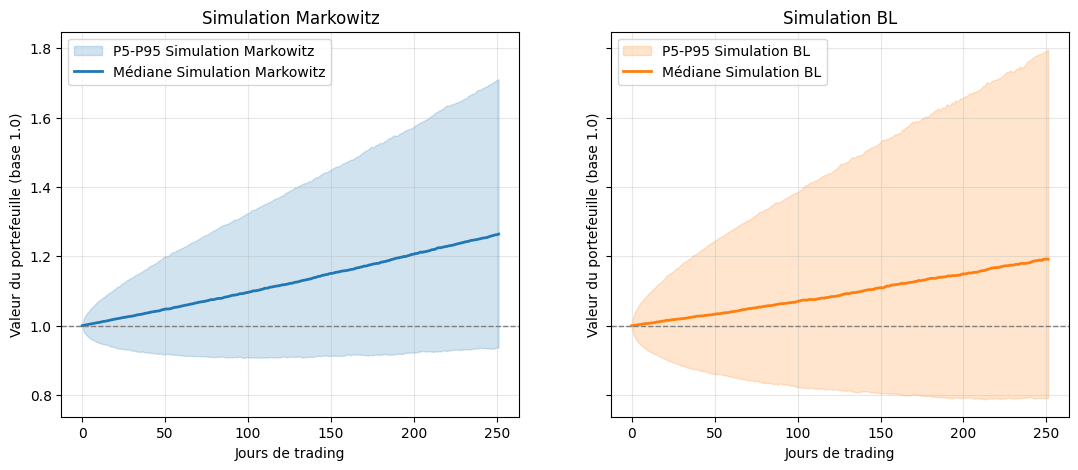

In [486]:
fig, axes = plt.subplots (1,2, figsize = (13,5), sharey=True)
fan_chart (sim_markowitz, axes [0], 'Simulation Markowitz', 'C0')
fan_chart (sim_bl, axes [1], 'Simulation BL', 'C1')           
plt.show()

# 6. Bootstrap sur les rendements

## 6.1. Bootstrap portefeuille de Markowitz

L'objectif ici est de comprendre l'erreur d'estimation de nos optimisations. A quel point les petites variations du vecteur rendements influence les poids optimaux de nos portefeuilles ?

In [487]:
#On génère plusieurs versions bruits du vecteur rendement
y_returns_boot = []
for i in range (500) :
    bruits = np.random.normal (loc = 0, scale = 0.015, size = y_returns.shape [0])
    boot = y_returns.values + bruits
    y_returns_boot.append (boot)

y_returns_boot = np.asarray (y_returns_boot)
print (y_returns_boot)
print (y_returns_boot.shape)

[[ 0.36204529  0.24834579  0.28053794 ...  0.22487613  0.1536887
  -0.05435464]
 [ 0.36428928  0.18750632  0.31065821 ...  0.26907217  0.14295356
  -0.03746152]
 [ 0.38206632  0.1983759   0.33214316 ...  0.23839978  0.16270364
  -0.02976535]
 ...
 [ 0.39556804  0.21762258  0.26523112 ...  0.25752213  0.16228178
  -0.04144658]
 [ 0.3695779   0.21977276  0.29741024 ...  0.22515804  0.15390774
  -0.03798808]
 [ 0.37122269  0.20964015  0.30727031 ...  0.2371577   0.17037589
  -0.0007604 ]]
(500, 10)


In [488]:
boot_wi_markowitz = []
for i in range (len (y_returns_boot)) :
    boot_opt = minimize (fun = lambda w : -portfolio_sharpe_ratio (w, y_returns_boot [i], y_cov, risk_free_rate),
                        x0 = np.repeat (1/len (y_returns), len(y_returns)),
                        method = 'SLSQP',
                        constraints = contraintes,
                        bounds = bornes)
    boot_wi_markowitz.append(boot_opt.x)
markowitz_boot = pd.DataFrame (boot_wi_markowitz,columns=y_returns.index)
print (round (markowitz_boot,4))

Ticker    AAPL     AMT    AMZN     CAT     GLD  JNJ  JPM     NEE      PG  XOM
0       0.3234  0.1455  0.1098  0.0169  0.2548  0.0  0.0  0.1496  0.0000  0.0
1       0.2622  0.0000  0.1890  0.0000  0.1978  0.0  0.0  0.3510  0.0000  0.0
2       0.2954  0.0000  0.2138  0.0000  0.2505  0.0  0.0  0.2404  0.0000  0.0
3       0.3796  0.0000  0.0900  0.0000  0.1854  0.0  0.0  0.3450  0.0000  0.0
4       0.3677  0.0241  0.1429  0.0000  0.2030  0.0  0.0  0.2430  0.0193  0.0
..         ...     ...     ...     ...     ...  ...  ...     ...     ...  ...
495     0.2750  0.0000  0.1536  0.0000  0.2647  0.0  0.0  0.1690  0.1378  0.0
496     0.3159  0.0000  0.1185  0.0000  0.1807  0.0  0.0  0.3849  0.0000  0.0
497     0.4314  0.0000  0.0210  0.0000  0.2528  0.0  0.0  0.2947  0.0000  0.0
498     0.3566  0.0416  0.1598  0.0000  0.2201  0.0  0.0  0.2219  0.0000  0.0
499     0.3182  0.0000  0.1748  0.0000  0.2363  0.0  0.0  0.2540  0.0168  0.0

[500 rows x 10 columns]


## 6.2. Bootstrap portefeuille BL

Pour le portefeuille BL, le bruit sera incorporé directement dans le vecteur de rendements du portefeuille de référence (ref_ret), ce qui modifiera direcetement le vecteur de rendements du portefeuille mixte (mu_bl). 
On aurait pu bruiter la matrice de covariance (y_cov) plutôt, ce qui aurait ensuite impacté le vecteur ref_ret mais aussi la matrice de covariance des erreurs d'estimation (omega). Mais par soucis de simpliciter nous abandonnerons cette option.

In [489]:
#Construction du vecteur ref_ret_boot
ref_ret_boot = []
for i in range (500) : 
    bruits = np.random.normal (loc = 0, scale = 0.015, size = ref_ret.shape [0])
    ref_ret_boot.append (ref_ret + bruits)

ref_ret_boot = np.asarray (ref_ret_boot)
print (ref_ret_boot)
print (ref_ret_boot.shape)

[[0.30287536 0.17091931 0.21606329 ... 0.09282883 0.08473989 0.1637403 ]
 [0.29908345 0.09656176 0.2346256  ... 0.08763514 0.12284068 0.15007917]
 [0.30145462 0.13783736 0.24068175 ... 0.07181614 0.08383073 0.15563393]
 ...
 [0.30932202 0.10256471 0.23030178 ... 0.10868282 0.09797847 0.15142728]
 [0.29193049 0.15507997 0.23081478 ... 0.10155746 0.10980274 0.16899253]
 [0.28696136 0.09583942 0.26354133 ... 0.11240096 0.1026618  0.15736825]]
(500, 10)


In [490]:
#Calcul du nouveau vecteur mu_bl_boot (vecteurs rendements du portefeuille mixte)
mu_bl_boot = []
for i in range (ref_ret_boot.shape [0]) :
    mu_bl_boot.append (M @ (tau_cov_inv @ ref_ret_boot [i] + P.T @ omega_inv @ Q))

mu_bl_boot = np.asarray (mu_bl_boot)
print (mu_bl_boot)
print (mu_bl_boot.shape)

[[0.25143768 0.16315555 0.19389667 ... 0.09575147 0.07451446 0.11773517]
 [0.24954173 0.09281474 0.20328233 ... 0.0999642  0.11577551 0.11100912]
 [0.25072731 0.1337496  0.20970318 ... 0.08261375 0.07636451 0.11717927]
 ...
 [0.25466101 0.09323068 0.19988671 ... 0.11204971 0.08750198 0.11044946]
 [0.24596525 0.15010239 0.20815941 ... 0.10890237 0.10182821 0.12724829]
 [0.24348068 0.09355806 0.23398112 ... 0.12242628 0.09716213 0.13089458]]
(500, 10)


In [491]:
#Calcul du nouveau vecteur poids boot_bl_wi
boot_bl_wi = []
for i in range (mu_bl_boot.shape [0]) : 
    boot_opt2 = minimize (fun = lambda w : -portfolio_sharpe_ratio (w, mu_bl_boot [i], cov_bl, risk_free_rate),
              x0= np.repeat (1/len (mu_bl), len (mu_bl)),
              method= 'SLSQP',
              constraints= contraintes,
              bounds= bornes)
    
    boot_bl_wi.append (boot_opt2.x)

bl_boot = pd.DataFrame (boot_bl_wi, columns= mu_bl.index)
print (bl_boot)
print (bl_boot.shape)


Ticker      AAPL           AMT      AMZN           CAT           GLD  \
0       0.565465  2.831252e-01  0.151410  0.000000e+00  2.855356e-17   
1       0.559530  0.000000e+00  0.234058  1.919387e-18  1.876207e-17   
2       0.567895  9.785815e-02  0.280233  0.000000e+00  3.715824e-17   
3       0.480665  1.099131e-01  0.289852  0.000000e+00  6.979551e-19   
4       0.423429  5.567218e-17  0.251154  0.000000e+00  8.581128e-18   
..           ...           ...       ...           ...           ...   
495     0.448026  2.379621e-02  0.355333  1.254964e-17  2.767426e-17   
496     0.557399  1.986837e-01  0.214878  4.038653e-18  3.523657e-19   
497     0.723332  6.852681e-18  0.218348  0.000000e+00  0.000000e+00   
498     0.495290  2.064465e-01  0.267359  1.019150e-17  5.475221e-18   
499     0.378082  0.000000e+00  0.432511  0.000000e+00  0.000000e+00   

Ticker           JNJ           JPM           NEE            PG           XOM  
0       2.051754e-17  5.347927e-18  2.020340e-17  4.6971

## 6.3. Comparaison de la stabilité des poids

In [492]:
# Écart-type des poids par actif, pour chaque modèle
std_markowitz = markowitz_boot.std()
std_bl = bl_boot.std()

stability = pd.DataFrame({
    'Markowitz (std)': std_markowitz,
    'Black-Litterman (std)': std_bl
})
stability['Ratio (MKW/BL)'] = stability['Markowitz (std)'] / stability['Black-Litterman (std)']

print(stability.round(4))
print ()
print(f'Écart-type moyen Markowitz : {std_markowitz.mean():.4f}')
print(f'Écart-type moyen BL        : {std_bl.mean():.4f}')

        Markowitz (std)  Black-Litterman (std)  Ratio (MKW/BL)
Ticker                                                        
AAPL             0.0602                 0.1279    4.706000e-01
AMT              0.0308                 0.0599    5.138000e-01
AMZN             0.0488                 0.0762    6.404000e-01
CAT              0.0063                 0.0103    6.095000e-01
GLD              0.0933                 0.0000    4.798388e+15
JNJ              0.0000                 0.0447    0.000000e+00
JPM              0.0000                 0.0521    0.000000e+00
NEE              0.0692                 0.0752    9.198000e-01
PG               0.0257                 0.0450    5.724000e-01
XOM              0.0000                 0.0347    0.000000e+00

Écart-type moyen Markowitz : 0.0334
Écart-type moyen BL        : 0.0526


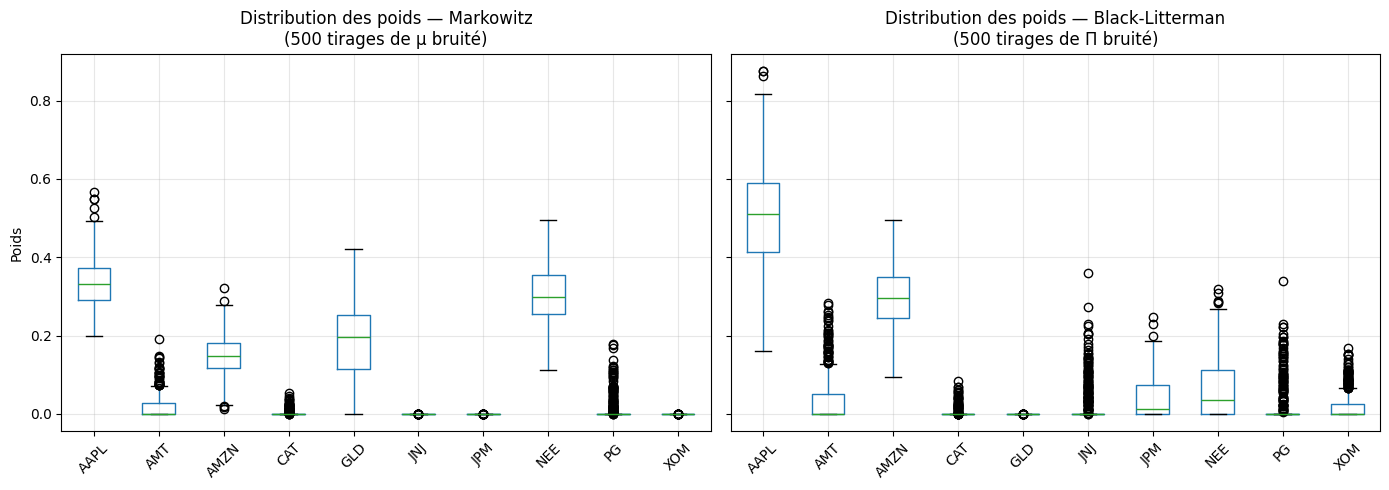

In [493]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

markowitz_boot.boxplot(ax=axes[0], rot=45)
axes[0].set_title('Distribution des poids — Markowitz\n(500 tirages de μ bruité)')
axes[0].set_ylabel('Poids')
axes[0].grid(alpha=0.3)

bl_boot.boxplot(ax=axes[1], rot=45)
axes[1].set_title('Distribution des poids — Black-Litterman\n(500 tirages de Π bruité)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Ces comparaisons sont très instructives. Le modèle Black-Litterman est souvent reconnu pour être meilleur pour l'allocation d'actif. Mais dans cette étude, on voit les écarts-types moyens pour le modèle BL supérieur à l'écart-type du modèle Markowitz. Suggérant que le modèle BL est moins stable pour l'allocation d'actifs. 

Cette suggestion se confirme avec l'observation des boxplots de chaque actif. Le modèle BL présente des boxplots plus larges avec plus de valeurs aberrantes. Le modèle BL est donc plus sensible aux petites variations pour l'allocation de poids optimaux et l'estimation de rendements.

Ces observations peuvent s'expliquer par le fait que le modèle BL compresse les rendement espérés vers l'équilibre

# 7. Conclusion

## 7.1. Métriques

In [494]:
# Métriques finales sur la période d'entraînement
final_metrics = pd.DataFrame({
    'Markowitz': {
        'Rendement espéré (μ_p)'  : portfolio_returns(sharpe_weights, y_returns),
        'Volatilité (σ_p)'        : portfolio_std(sharpe_weights, y_cov),
        'Ratio de Sharpe'         : portfolio_sharpe_ratio(sharpe_weights, y_returns, y_cov, risk_free_rate),
    },
    'Black-Litterman': {
        'Rendement espéré (μ_p)'  : portfolio_returns(np.asarray(wi_bl).reshape(-1), mu_bl),
        'Volatilité (σ_p)'        : portfolio_std(np.asarray(wi_bl).reshape(-1), cov_bl),
        'Ratio de Sharpe'         : portfolio_sharpe_ratio(np.asarray(wi_bl).reshape(-1), mu_bl, cov_bl, risk_free_rate),
    }
}).T

print(f'Métriques rendement - risque : \n {final_metrics.round(4)}')

Métriques rendement - risque : 
                  Rendement espéré (μ_p)  Volatilité (σ_p)  Ratio de Sharpe
Markowitz                        0.2688            0.1815           1.2492
Black-Litterman                  0.2194            0.2501           0.7093


In [495]:
# Métriques Monte Carlo
final_mc = pd.DataFrame({
    'Markowitz': {
        'Médiane simulée (1 an)'  : np.median(sim_markowitz[:, -1]),
        'P5  (queue basse)'       : np.percentile(sim_markowitz[:, -1], 5),
        'P95 (queue haute)'       : np.percentile(sim_markowitz[:, -1], 95),
        'VaR 95%'                 : np.percentile(1 - sim_markowitz[:, -1], 95),
        'CVaR 95%'                : (1 - sim_markowitz[:, -1])[
                                        (1 - sim_markowitz[:, -1]) >= np.percentile(1 - sim_markowitz[:, -1], 95)
                                    ].mean(),
    },
    'Black-Litterman': {
        'Médiane simulée (1 an)'  : np.median(sim_bl[:, -1]),
        'P5  (queue basse)'       : np.percentile(sim_bl[:, -1], 5),
        'P95 (queue haute)'       : np.percentile(sim_bl[:, -1], 95),
        'VaR 95%'                 : np.percentile(1 - sim_bl[:, -1], 95),
        'CVaR 95%'                : (1 - sim_bl[:, -1])[
                                        (1 - sim_bl[:, -1]) >= np.percentile(1 - sim_bl[:, -1], 95)
                                    ].mean(),
    }
}).T

print(f'Métriques Monte Carlo : \n {final_mc.round (4)}')
print ()
print(f'Stabilité des poids (écart-type bootstrap) :\n {stability.round(4)}')


Métriques Monte Carlo : 
                  Médiane simulée (1 an)  P5  (queue basse)  P95 (queue haute)  \
Markowitz                        1.2641             0.9372             1.7104   
Black-Litterman                  1.1915             0.7923             1.7972   

                 VaR 95%  CVaR 95%  
Markowitz         0.0628    0.1327  
Black-Litterman   0.2077    0.2868  

Stabilité des poids (écart-type bootstrap) :
         Markowitz (std)  Black-Litterman (std)  Ratio (MKW/BL)
Ticker                                                        
AAPL             0.0602                 0.1279    4.706000e-01
AMT              0.0308                 0.0599    5.138000e-01
AMZN             0.0488                 0.0762    6.404000e-01
CAT              0.0063                 0.0103    6.095000e-01
GLD              0.0933                 0.0000    4.798388e+15
JNJ              0.0000                 0.0447    0.000000e+00
JPM              0.0000                 0.0521    0.000000e+00
NEE  

Le modèle Markowitz domine le modèle BL sur les métriques historiques classiques : rendement plus élevé (26.9% vs 22.0%), volatilité plus faible (18.2% vs 25.1%), et Sharpe nettement supérieur (1.25 vs 0.71).

La simulation de Monte Carlo montre que le risque de queue du modèle BL est dramatiquement plus élevé. Dans les 5% pires scénarios, le portefeuille BL perd en moyenne 28.8% contre 13.3% pour le modèle Markowitz. Cela s'explique directement par la volatilité plus élevée de BL (25% vs 18%) combinée à une médiane plus faible — le GBM amplifie cet écart sur un an.



## 7.2. Représentation graphique

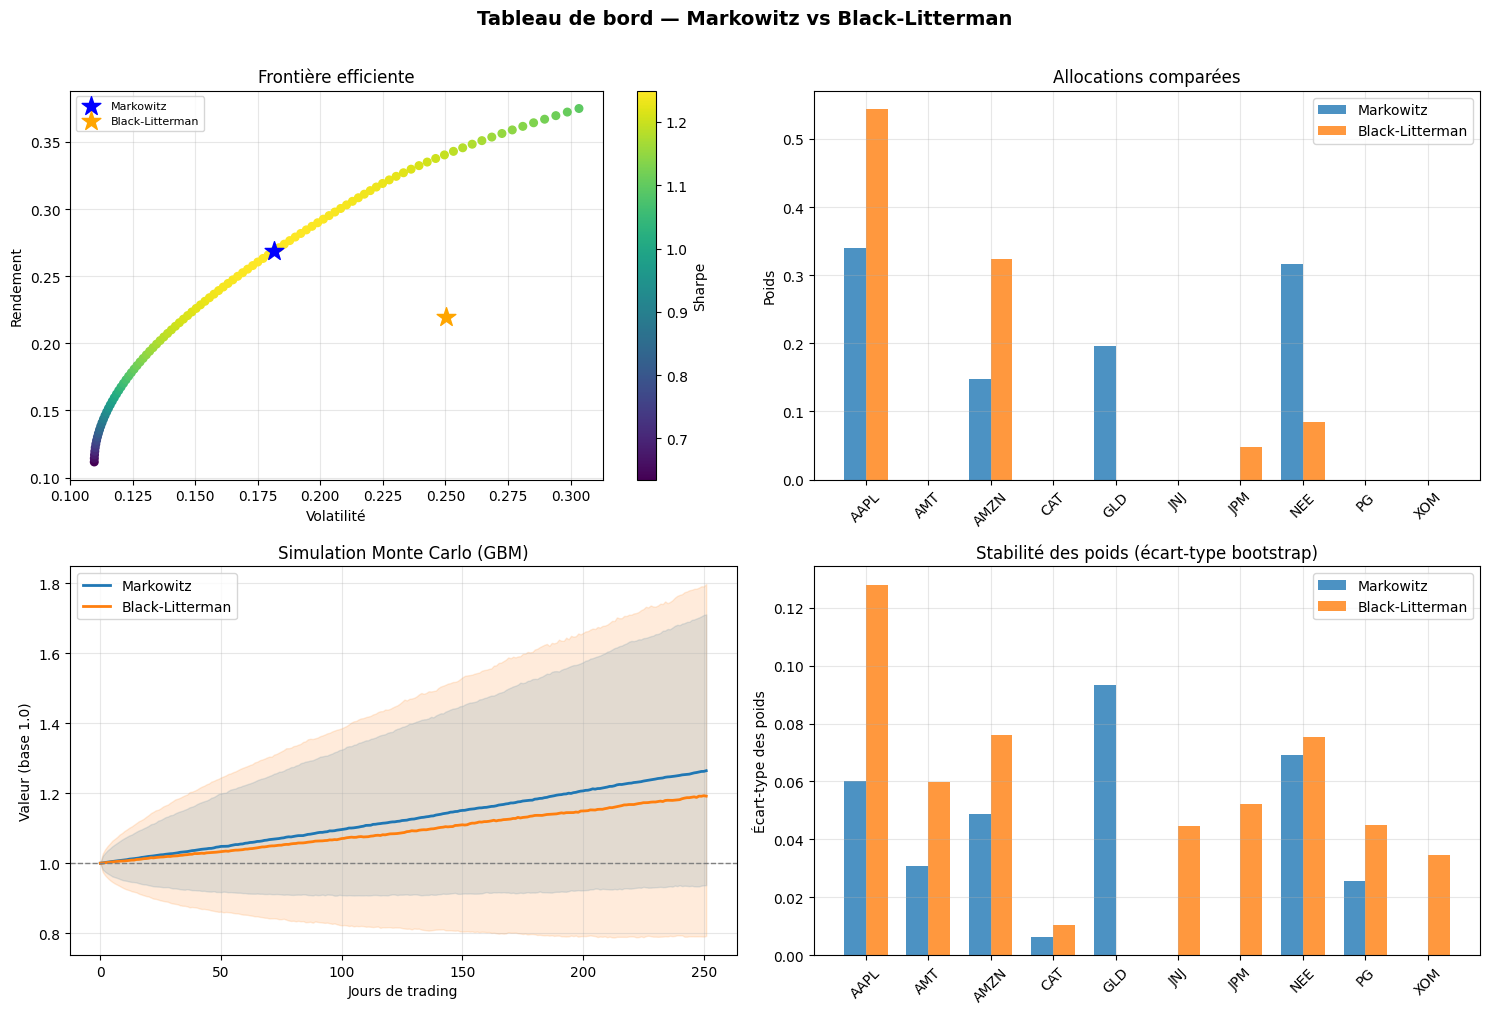

In [496]:
# ── Graphique de synthèse ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))

# 1. Frontière efficiente + points BL et Markowitz
ax1 = fig.add_subplot(2, 2, 1)
sc = ax1.scatter(eff_front['Port_std'], eff_front['Port_Return'],
                 c=eff_front['Sharpe_R'], cmap='viridis', s=30, zorder=2)
plt.colorbar(sc, ax=ax1, label='Sharpe')
ax1.scatter(portfolio_std(sharpe_weights, y_cov),
            portfolio_returns(sharpe_weights, y_returns),
            c='blue', marker='*', s=200, zorder=3, label='Markowitz')
ax1.scatter(portfolio_std(np.asarray(wi_bl).reshape(-1), cov_bl),
            portfolio_returns(np.asarray(wi_bl).reshape(-1), mu_bl),
            c='orange', marker='*', s=200, zorder=3, label='Black-Litterman')
ax1.set_title('Frontière efficiente')
ax1.set_xlabel('Volatilité')
ax1.set_ylabel('Rendement')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# 2. Allocation des poids
ax2 = fig.add_subplot(2, 2, 2)
x = np.arange(len(y_returns.index))
width = 0.35
ax2.bar(x - width/2, sharpe_weights, width, label='Markowitz', color='C0', alpha=0.8)
ax2.bar(x + width/2, np.asarray(wi_bl).reshape(-1), width, label='Black-Litterman', color='C1', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(y_returns.index, rotation=45)
ax2.set_title('Allocations comparées')
ax2.set_ylabel('Poids')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Fan chart superposé
ax3 = fig.add_subplot(2, 2, 3)
days = np.arange(sim_markowitz.shape[1])
for sim, color, label in [(sim_markowitz, 'C0', 'Markowitz'), (sim_bl, 'C1', 'Black-Litterman')]:
    p5  = np.percentile(sim, 5,  axis=0)
    p50 = np.percentile(sim, 50, axis=0)
    p95 = np.percentile(sim, 95, axis=0)
    ax3.fill_between(days, p5, p95, alpha=0.15, color=color)
    ax3.plot(days, p50, color=color, linewidth=2, label=label)
ax3.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax3.set_title('Simulation Monte Carlo (GBM)')
ax3.set_xlabel('Jours de trading')
ax3.set_ylabel('Valeur (base 1.0)')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Stabilité des poids (bootstrap)
ax4 = fig.add_subplot(2, 2, 4)
x = np.arange(len(y_returns.index))
ax4.bar(x - width/2, markowitz_boot.std(), width, label='Markowitz', color='C0', alpha=0.8)
ax4.bar(x + width/2, bl_boot.std(),     width, label='Black-Litterman', color='C1', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(y_returns.index, rotation=45)
ax4.set_title('Stabilité des poids (écart-type bootstrap)')
ax4.set_ylabel('Écart-type des poids')
ax4.legend()
ax4.grid(alpha=0.3)

plt.suptitle('Tableau de bord — Markowitz vs Black-Litterman', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()